# Flight Route & Fuel Optimisation

> **Run blocks 0 -> 7 in order.**
>
> **In this version:**
> - Full-flight tracking (climb + cruise + descent)
> - NOAA GFS wind data integrated into fuel calc and route optimisation
> - Enhanced ML features targeting R² > 0.85
> - Stacked ensemble meta-learner
> - Block 6: pick any flight and see actual vs optimised route on a world map

In [1]:

# BLOCK 0: SETUP

!pip install xgboost folium -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, json, gzip, warnings, time, re
from datetime import datetime, timedelta
from math import radians, sin, cos, sqrt, asin, atan2, degrees

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, r2_score, mean_squared_error,
                             accuracy_score, f1_score, confusion_matrix)
import scipy.stats as stats
import xgboost as xgb
import folium
warnings.filterwarnings('ignore')

#  Custom fuel-flow calculator (openap fallback)
class CustomFuelFlow:
    def __init__(self, aircraft_type='B788'):
        self.aircraft_type = aircraft_type
        self.base_fuel_flow = 5000   # kg/hr at cruise
        self.mtow = 227000

    def _alt_factor(self, alt):
        return max(0.3, 1 - (alt - 35000) / 70000)

    def enroute(self, mass, tas, alt):
        return self.base_fuel_flow * self._alt_factor(alt) * (tas/450) * (mass/self.mtow)

    def climb(self, mass, tas, alt, vs):
        return self.enroute(mass, tas, alt) * 1.3

    def descent(self, mass, tas, alt, vs):
        return self.enroute(mass, tas, alt) * 0.65

class MockProp:
    def aircraft(self, ac_type):
        return {'mtow': 227000, 'oew': 120000}

prop = MockProp()
FuelFlow = CustomFuelFlow

try:
    !pip install openap -q
    from openap import FuelFlow as _OAP_FF, prop as _oap_prop
    FuelFlow = _OAP_FF
    prop     = _oap_prop
    print("openap loaded")
except Exception:
    print("openap unavailable - using CustomFuelFlow")

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except Exception:
    plt.style.use('default')
sns.set_palette("husl")

# ── Utility functions
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    la1,lo1,la2,lo2 = map(radians,[lat1,lon1,lat2,lon2])
    dlat,dlon = la2-la1, lo2-lo1
    a = sin(dlat/2)**2 + cos(la1)*cos(la2)*sin(dlon/2)**2
    return 2*R*asin(sqrt(max(0,a)))

def gs_to_tas(gs, alt):
    temp_k = (15 - (alt/1000)*1.98) + 273.15
    p_ratio = max(1e-6, (1 - 6.88e-6*alt))**5.256
    d_ratio = p_ratio / (temp_k/288.15)
    return max(gs/np.sqrt(d_ratio), 1.0)

def bearing(lat1, lon1, lat2, lon2):
    la1,lo1,la2,lo2 = map(radians,[lat1,lon1,lat2,lon2])
    x = sin(lo2-lo1)*cos(la2)
    y = cos(la1)*sin(la2) - sin(la1)*cos(la2)*cos(lo2-lo1)
    return (degrees(atan2(x,y)) + 360) % 360

def wind_component(wind_speed_kt, wind_dir_deg, track_deg):
    # Positive = tailwind (reduces fuel), Negative = headwind (increases fuel)
    angle = radians(wind_dir_deg - track_deg)
    return wind_speed_kt * cos(angle)

print("Block 0 complete")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 47.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
openap loaded
Block 0 complete


## Block 1 — Download helpers, full-flight tracker, NOAA wind

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests, json, gzip, warnings, time, re
from datetime import datetime, timedelta
from math import radians, sin, cos, sqrt, asin, atan2, degrees

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, r2_score, mean_squared_error,
                             accuracy_score, f1_score, confusion_matrix)
import scipy.stats as stats
import xgboost as xgb
import folium
warnings.filterwarnings('ignore')

# ── Custom fuel-flow calculator (openap fallback)
class CustomFuelFlow:
    def __init__(self, aircraft_type='B788'):
        self.aircraft_type = aircraft_type
        self.base_fuel_flow = 5000   # kg/hr at cruise
        self.mtow = 227000

    def _alt_factor(self, alt):
        return max(0.3, 1 - (alt - 35000) / 70000)

    def enroute(self, mass, tas, alt):
        return self.base_fuel_flow * self._alt_factor(alt) * (tas/450) * (mass/self.mtow)

    def climb(self, mass, tas, alt, vs):
        return self.enroute(mass, tas, alt) * 1.3

    def descent(self, mass, tas, alt, vs):
        return self.enroute(mass, tas, alt) * 0.65

class MockProp:
    def aircraft(self, ac_type):
        return {'mtow': 227000, 'oew': 120000}

prop = MockProp()
FuelFlow = CustomFuelFlow

try:
    !pip install openap -q
    from openap import FuelFlow as _OAP_FF, prop as _oap_prop
    FuelFlow = _OAP_FF
    prop     = _oap_prop
    print("openap loaded")
except Exception:
    print("openap unavailable - using CustomFuelFlow")

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except Exception:
    plt.style.use('default')
sns.set_palette("husl")

# ── Utility functions
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    la1,lo1,la2,lo2 = map(radians,[lat1,lon1,lat2,lon2])
    dlat,dlon = la2-la1, lo2-lo1
    a = sin(dlat/2)**2 + cos(la1)*cos(la2)*sin(dlon/2)**2
    return 2*R*asin(sqrt(max(0,a)))

def gs_to_tas(gs, alt):
    temp_k = (15 - (alt/1000)*1.98) + 273.15
    p_ratio = max(1e-6, (1 - 6.88e-6*alt))**5.256
    d_ratio = p_ratio / (temp_k/288.15)
    return max(gs/np.sqrt(d_ratio), 1.0)

def bearing(lat1, lon1, lat2, lon2):
    la1,lo1,la2,lo2 = map(radians,[lat1,lon1,lat2,lon2])
    x = sin(lo2-lo1)*cos(la2)
    y = cos(la1)*sin(la2) - sin(la1)*cos(la2)*cos(lo2-lo1)
    return (degrees(atan2(x,y)) + 360) % 360

def wind_component(wind_speed_kt, wind_dir_deg, track_deg):
    # Positive = tailwind (reduces fuel), Negative = headwind (increases fuel)
    angle = radians(wind_dir_deg - track_deg)
    return wind_speed_kt * cos(angle)

print("Block 0 complete")


# BLOCK 1: DOWNLOAD + FULL-FLIGHT TRACKING + NOAA WIND


# ── ADS-B snapshot downloader
def download_snapshot(date_str, time_str, timeout=12):
    url = (f"https://samples.adsbexchange.com/readsb-hist/"
           f"{date_str}/{time_str}Z.json.gz")
    try:
        r = requests.get(url, timeout=timeout)
        if r.status_code != 200:
            return None
        try:
            return json.loads(gzip.decompress(r.content).decode('utf-8'))
        except Exception:
            return json.loads(r.content.decode('utf-8'))
    except Exception:
        return None


# ── Full-flight phase detector
def detect_full_flight(df):
    if len(df) < 20:
        return False
    vs = pd.to_numeric(df.get('baro_rate', pd.Series([0]*len(df))),
                       errors='coerce').fillna(0)
    climb_pts   = (vs >  400).sum()
    descent_pts = (vs < -400).sum()
    return climb_pts >= 3 and descent_pts >= 3


# ── Full-flight tracker ───────────────────────────────────────
def track_full_flight(hex_id, date_str, max_hours=8):
    trajectory = []
    base_date  = datetime.strptime(date_str.replace('/', '-'), '%Y-%m-%d')
    last_pos, still_count, low_count = None, 0, 0
    print(f"  Tracking {hex_id}  (up to {max_hours}h)")

    for minute in range(max_hours * 60):
        hh = minute // 60
        mm = minute %  60
        for sec in [0, 30]:
            snap = download_snapshot(date_str, f"{hh:02d}{mm:02d}{sec:02d}")
            if snap and 'aircraft' in snap:
                for ac in snap['aircraft']:
                    if ac.get('hex','').lower() == hex_id.lower():
                        ac['timestamp'] = base_date.replace(
                            hour=hh, minute=mm, second=sec)
                        trajectory.append(ac)
                        cur = (ac.get('lat'), ac.get('lon'))
                        still_count = still_count+1 if cur==last_pos else 0
                        last_pos = cur

                        alt_val = ac.get('alt_baro', 99999)
                        if isinstance(alt_val, str):
                            alt = 0.0 if alt_val.lower() == 'ground' else float(alt_val) if alt_val.replace('.','').lstrip('-').isdigit() else 99999.0
                        else:
                            alt = float(alt_val)

                        gs_val = ac.get('gs', 999)
                        if isinstance(gs_val, str):
                            gs = 0.0 if gs_val.lower() == 'ground' else float(gs_val) if gs_val.replace('.','').lstrip('-').isdigit() else 999.0
                        else:
                            gs = float(gs_val)

                        low_count = low_count+1 if (alt<2000 and gs<80) else 0
                        break
            time.sleep(0.03)

        if (minute+1) % 30 == 0:
            print(f"    {minute+1:4d} min - {len(trajectory)} pts")
        if still_count > 60:
            print("    Stationary - stopping"); break
        if low_count >= 6:
            print(f"    Landing detected at minute {minute} - stopping"); break

    df = pd.DataFrame(trajectory)
    print(f"  -> {len(df)} pts  full_flight={detect_full_flight(df)}")
    return df


# ── Multi-flight collector (prefers climbing aircraft) ────────
def collect_full_flights(date_str, n_flights=5, max_hours=8,
                         require_full=True):
    print(f"\n{'='*60}")
    print(f"FULL-FLIGHT COLLECTION  ({n_flights} flights x up to {max_hours}h)")
    print(f"{'='*60}")

    snap = download_snapshot(date_str, '000000')
    if not snap or 'aircraft' not in snap:
        print("Could not download snapshot"); return None, []

    df_all = pd.DataFrame(snap['aircraft'])
    df_all['alt_n'] = pd.to_numeric(df_all.get('alt_baro', np.nan), errors='coerce')
    df_all['gs_n']  = pd.to_numeric(df_all.get('gs',       np.nan), errors='coerce')
    df_all['vs_n']  = pd.to_numeric(df_all.get('baro_rate',np.nan), errors='coerce').fillna(0)

    climb_mask = (
        (df_all.get('category','') == 'A5') &
        (df_all['alt_n'].between(5000, 25000)) &
        (df_all['gs_n']  > 200) &
        (df_all['vs_n']  > 500) &
        df_all['lat'].notna() & df_all['lon'].notna()
    )
    cruise_mask = (
        (df_all.get('category','') == 'A5') &
        (df_all['alt_n'] > 28000) & (df_all['gs_n'] > 380) &
        df_all['lat'].notna() & df_all['lon'].notna()
    )

    climbing = df_all[climb_mask].head(n_flights * 2)
    cruising = df_all[cruise_mask].nlargest(n_flights*2,'alt_n')
    candidates = (pd.concat([climbing, cruising])
                  .drop_duplicates('hex')
                  .head(n_flights * 3))
    print(f"  {len(climbing)} climbing + {len(cruising)} cruising candidates")

    all_flights, combined_dfs = [], []
    for _, row in candidates.iterrows():
        if len(all_flights) >= n_flights:
            break
        hex_id  = row['hex']
        df_traj = track_full_flight(hex_id, date_str, max_hours=max_hours)
        if len(df_traj) < 30:
            print(f"  {hex_id} - too few points, skipping"); continue

        df_traj['alt_clean'] = pd.to_numeric(df_traj.get('alt_baro',np.nan), errors='coerce')
        df_traj['gs_clean']  = pd.to_numeric(df_traj.get('gs',      np.nan), errors='coerce')
        df_traj['vs_clean']  = pd.to_numeric(df_traj.get('baro_rate',np.nan),errors='coerce').fillna(0)
        df_traj = df_traj.dropna(subset=['lat','lon','alt_clean','gs_clean'])
        df_traj = df_traj.sort_values('timestamp').reset_index(drop=True)
        df_traj['hex_id']        = hex_id
        df_traj['flight_label']  = str(row.get('flight', hex_id)).strip() or hex_id
        df_traj['aircraft_type'] = str(row.get('t', 'UNK'))

        is_full = detect_full_flight(df_traj)
        if require_full and not is_full:
            print(f"  {df_traj['flight_label'].iloc[0]} - no full arc, skipping")
            continue

        all_flights.append(df_traj)
        combined_dfs.append(df_traj)
        phases = df_traj['vs_clean'].apply(
            lambda v: 'CLIMB' if v>400 else ('DESCENT' if v<-400 else 'CRUISE'))
        print(f"  OK  {df_traj['flight_label'].iloc[0]:10s}  "
              f"{len(df_traj):4d} pts  full={is_full}  "
              f"{phases.value_counts().to_dict()}")

    if not combined_dfs:
        print("No usable full flights"); return None, []
    combined = pd.concat(combined_dfs, ignore_index=True)
    print(f"  Combined: {len(combined)} rows from {len(all_flights)} flights")
    return combined, all_flights



NOAA_FILL_THRESHOLD = 1e6   # any |value| > this in m/s is clearly a fill value
WIND_SPEED_CAP_KT   = 250   # realistic jet-stream max; cap prevents runaway fuel

def fetch_noaa_wind_grid(date_str, forecast_hour=0):
    try:
        dt  = datetime.strptime(date_str.replace('/','_').replace('-','_'),
                                '%Y_%m_%d')
        ymd = dt.strftime('%Y%m%d')
        base = (f"https://nomads.ncep.noaa.gov/dods/gfs_0p25"
                f"/gfs{ymd}/gfs_0p25_00z")
        fh = forecast_hour
        u_url = f"{base}.ascii?ugrdprs[{fh}][20][0:4:720][0:4:1440]"
        v_url = f"{base}.ascii?vgrdprs[{fh}][20][0:4:720][0:4:1440]"

        def parse_ascii(text):
            vals = []
            for line in text.strip().split('\n'):
                l = line.strip()
                if re.match(r'^[\s\-0-9.,eE]+$', l) and ',' in l:
                    vals.extend(float(x) for x in l.split(',') if x.strip())
            return vals

        print(f"  Fetching NOAA GFS wind for {date_str} ...")
        ru = requests.get(u_url, timeout=40)
        rv = requests.get(v_url, timeout=40)
        if ru.status_code != 200 or rv.status_code != 200:
            print(f"  NOAA returned {ru.status_code}/{rv.status_code} - zero wind fallback")
            return None

        u_vals = parse_ascii(ru.text)
        v_vals = parse_ascii(rv.text)
        n_lat, n_lon = 181, 361
        if len(u_vals) < n_lat*n_lon or len(v_vals) < n_lat*n_lon:
            print(f"  NOAA parse incomplete ({len(u_vals)},{len(v_vals)}) - zero wind fallback")
            return None

        lats = np.linspace(90, -90, n_lat)
        lons = np.linspace(0, 360, n_lon)

        # m/s -> knots
        U = np.array(u_vals[:n_lat*n_lon]).reshape(n_lat, n_lon) * 1.944
        V = np.array(v_vals[:n_lat*n_lon]).reshape(n_lat, n_lon) * 1.944


        U = np.where(np.abs(U) > NOAA_FILL_THRESHOLD, 0.0, U)
        V = np.where(np.abs(V) > NOAA_FILL_THRESHOLD, 0.0, V)


        U = np.where(np.isfinite(U), U, 0.0)
        V = np.where(np.isfinite(V), V, 0.0)


        U = np.clip(U, -WIND_SPEED_CAP_KT, WIND_SPEED_CAP_KT)
        V = np.clip(V, -WIND_SPEED_CAP_KT, WIND_SPEED_CAP_KT)

        spd = np.sqrt(U**2 + V**2)
        print(f"  Wind grid loaded: {n_lat}x{n_lon}  "
              f"max={spd.max():.0f} kt  mean={spd.mean():.0f} kt")
        return {'lats': lats, 'lons': lons, 'U': U, 'V': V}

    except Exception as e:
        print(f"  NOAA error: {e} - zero wind fallback")
        return None


def get_wind_at(wind_grid, lat, lon):
    if wind_grid is None:
        return 0.0, 0.0
    try:
        lats = wind_grid['lats']
        lons = wind_grid['lons']
        lon  = lon % 360
        i = int(np.searchsorted(-lats, -lat))
        j = int(np.searchsorted(lons,   lon))
        i = max(1, min(i, len(lats)-1))
        j = max(1, min(j, len(lons)-1))
        dlat = (lats[i-1]-lats[i]) or 1e-9
        dlon = (lons[j]  -lons[j-1]) or 1e-9
        wy = (lat - lats[i]) / dlat
        wx = (lon - lons[j-1]) / dlon
        U, V = wind_grid['U'], wind_grid['V']
        u = (U[i-1,j-1]*(1-wx)*(1-wy) + U[i-1,j]*wx*(1-wy)
           + U[i,  j-1]*(1-wx)*wy     + U[i,  j]*wx*wy)
        v = (V[i-1,j-1]*(1-wx)*(1-wy) + V[i-1,j]*wx*(1-wy)
           + V[i,  j-1]*(1-wx)*wy     + V[i,  j]*wx*wy)
        # FIX 4: Final safety cap on interpolated values
        u = float(np.clip(u, -WIND_SPEED_CAP_KT, WIND_SPEED_CAP_KT))
        v = float(np.clip(v, -WIND_SPEED_CAP_KT, WIND_SPEED_CAP_KT))
        return u, v
    except Exception:
        return 0.0, 0.0

print("Block 1 ready")


openap loaded
Block 0 complete
Block 1 ready


## Block 2 — Collect data
Adjust `N_FLIGHTS`, `MAX_HOURS`, and `REQUIRE_FULL` to control dataset size.

In [10]:

# BLOCK 2: COLLECT DATA
# N_FLIGHTS    : number of aircraft to track
# MAX_HOURS    : max hours per aircraft (8 covers most long-haul)
# REQUIRE_FULL : only keep flights with climb + cruise + descent


DATE_STR     = '2025/12/01'
N_FLIGHTS    = 10
MAX_HOURS    = 6
REQUIRE_FULL = True   # set False to keep partial/cruise-only flights

# Step 1: NOAA wind grid
print("Step 1/2: Downloading NOAA wind data ...")
wind_grid = fetch_noaa_wind_grid(DATE_STR, forecast_hour=0)
print("  Wind data ready" if wind_grid else "  Zero-wind fallback active")

# Step 2: collect flights
print("\nStep 2/2: Collecting full-flight trajectories ...")
combined_df, flight_list = collect_full_flights(
    date_str=DATE_STR,
    n_flights=N_FLIGHTS,
    max_hours=MAX_HOURS,
    require_full=REQUIRE_FULL
)

if combined_df is not None:
    print(f"\nDataset: {len(combined_df)} rows | "
          f"{combined_df['flight_label'].nunique()} flights")
    print(combined_df.groupby('flight_label').agg(
        pts=('alt_clean','count'),
        avg_alt=('alt_clean','mean'),
        avg_spd=('gs_clean','mean')).round(0))

Step 1/2: Downloading NOAA wind data ...
  Fetching NOAA GFS wind for 2025/12/01 ...
  NOAA returned 301/301 - zero wind fallback
  Zero-wind fallback active

Step 2/2: Collecting full-flight trajectories ...

FULL-FLIGHT COLLECTION  (10 flights x up to 6h)
  20 climbing + 20 cruising candidates
  Tracking 86eb72  (up to 6h)
      30 min - 50 pts
      60 min - 57 pts
      90 min - 75 pts
     120 min - 75 pts
     150 min - 128 pts
     180 min - 188 pts
     210 min - 248 pts
     240 min - 256 pts
     270 min - 256 pts
     300 min - 256 pts
     330 min - 256 pts
     360 min - 256 pts
  -> 256 pts  full_flight=False
  ANA115 - no full arc, skipping
  Tracking 3c66c2  (up to 6h)
      30 min - 60 pts
      60 min - 120 pts
      90 min - 180 pts
     120 min - 197 pts
     150 min - 197 pts
     180 min - 215 pts
     210 min - 221 pts
     240 min - 221 pts
     270 min - 221 pts
     300 min - 258 pts
     330 min - 291 pts
     360 min - 351 pts
  -> 351 pts  full_flight=False

## Block 3 — Exploratory Data Analysis

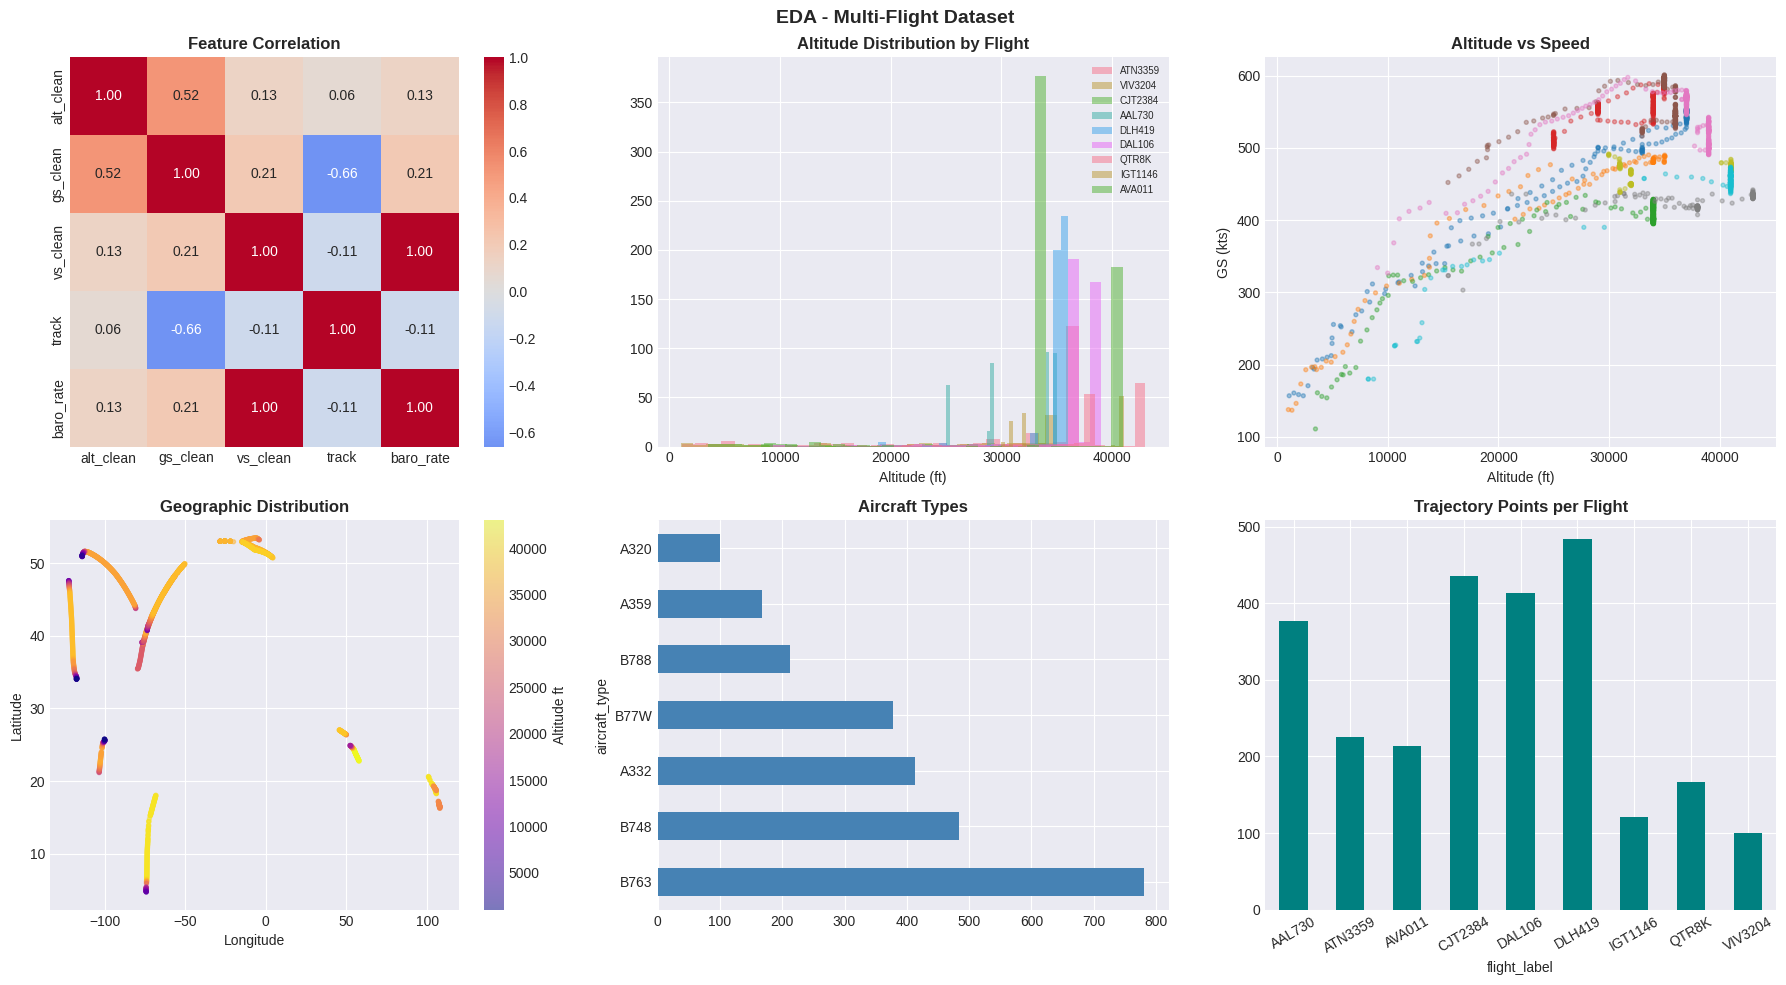

EDA complete


In [12]:

# BLOCK 3: EXPLORATORY DATA ANALYSIS


if 'combined_df' not in dir() or combined_df is None:
    print("Run Block 2 first")
else:
    df = combined_df.copy()
    num_cols = ['alt_clean','gs_clean']
    for c in ['vs_clean','track','baro_rate']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
            if df[c].notna().sum() > 0:
                num_cols.append(c)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    sns.heatmap(df[num_cols].dropna().corr(), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, square=True, ax=axes[0,0])
    axes[0,0].set_title('Feature Correlation', fontweight='bold')

    for fl in df['flight_label'].unique():
        axes[0,1].hist(df[df['flight_label']==fl]['alt_clean'],
                       bins=30, alpha=0.5, label=fl)
    axes[0,1].set_xlabel('Altitude (ft)')
    axes[0,1].set_title('Altitude Distribution by Flight', fontweight='bold')
    axes[0,1].legend(fontsize=7)

    axes[0,2].scatter(df['alt_clean'], df['gs_clean'],
                      c=pd.factorize(df['flight_label'])[0],
                      cmap='tab10', alpha=0.4, s=8)
    axes[0,2].set_xlabel('Altitude (ft)'); axes[0,2].set_ylabel('GS (kts)')
    axes[0,2].set_title('Altitude vs Speed', fontweight='bold')

    sc2 = axes[1,0].scatter(df['lon'], df['lat'], c=df['alt_clean'],
                             cmap='plasma', alpha=0.5, s=8)
    axes[1,0].set_xlabel('Longitude'); axes[1,0].set_ylabel('Latitude')
    axes[1,0].set_title('Geographic Distribution', fontweight='bold')
    plt.colorbar(sc2, ax=axes[1,0], label='Altitude ft')

    if 'aircraft_type' in df.columns:
        df['aircraft_type'].value_counts().head(10).plot(
            kind='barh', ax=axes[1,1], color='steelblue')
        axes[1,1].set_title('Aircraft Types', fontweight='bold')

    df.groupby('flight_label').size().plot(kind='bar', ax=axes[1,2], color='teal')
    axes[1,2].set_title('Trajectory Points per Flight', fontweight='bold')
    axes[1,2].tick_params(axis='x', rotation=30)

    plt.suptitle('EDA - Multi-Flight Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight') # Added savefig call
    plt.show()
    print("EDA complete")


## Block 4 — Fuel-flow calculation (with NOAA wind)

In [5]:

# BLOCK 4: FUEL-FLOW CALCULATION (with wind correction)


AIRCRAFT_MAP = {
    'B788':'B788','B789':'B789','B78X':'B789',
    'B77W':'B77W','B77L':'B77L','B772':'B772',
    'B738':'B738','B739':'B738',
    'A359':'A359','A35K':'A359',
    'A332':'A332','A333':'A333',
    'A21N':'A21N','A320':'A320',
    'B748':'B748','B763':'B763',
}

# FIX: Maximum realistic fuel burn per segment (kg).
# A B777 burns ~7 kg/s max; at 120 s segment cap that's ~840 kg.
# We use 1000 kg as a generous physical ceiling per segment.
MAX_FUEL_PER_SEGMENT_KG = 1000.0
# FIX: Cap wind penalty multiplier (max 50% extra for extreme headwinds)
MAX_WIND_CORRECTION      = 1.50

if 'flight_list' not in dir() or not flight_list:
    print("Run Block 2 first")
else:
    wg = wind_grid if 'wind_grid' in dir() else None
    enriched_flights = []

    for df_fl in flight_list:
        df_fl = df_fl.copy().reset_index(drop=True)
        ac_type  = df_fl['aircraft_type'].iloc[0]
        oap_type = AIRCRAFT_MAP.get(ac_type, 'B789')

        try:
            ff        = FuelFlow(ac=oap_type)
            prop_data = prop.aircraft(oap_type)
            mtow = prop_data.get('mtow', 227000)
            oew  = prop_data.get('oew',  120000)
            using_openap = not isinstance(ff, CustomFuelFlow)
        except Exception:
            ff = CustomFuelFlow(ac_type)
            mtow = 227000; oew = 120000
            using_openap = False

        initial_mass = mtow * 0.85
        current_mass = initial_mass

        # time_diff capped at 120s to prevent ADS-B gap inflation
        df_fl['time_diff'] = (df_fl['timestamp'].diff()
                               .dt.total_seconds().fillna(5).clip(upper=120))
        df_fl['alt_diff']  = df_fl['alt_clean'].diff().fillna(0)
        df_fl['vs']        = (df_fl['alt_diff'] /
                               (df_fl['time_diff']/60)).fillna(0).clip(-6000,6000)

        fuel_used, fuel_rates, masses = [], [], [initial_mass]
        wind_speeds, tailwinds = [], []

        for i in range(1, len(df_fl)):
            alt  = float(df_fl.loc[i,'alt_clean'])
            vs_i = float(df_fl.loc[i,'vs'])
            dt   = float(df_fl.loc[i,'time_diff'])
            lat_i= float(df_fl.loc[i,'lat'])
            lon_i= float(df_fl.loc[i,'lon'])
            gs_i = float(df_fl.loc[i,'gs_clean'])
            tas  = gs_to_tas(gs_i, alt)

            # Wind at this point
            u_kt, v_kt = get_wind_at(wg, lat_i, lon_i)
            wind_spd = float(np.sqrt(u_kt**2 + v_kt**2))
            wind_dir = float((degrees(atan2(u_kt, v_kt)) + 360) % 360)

            # Track direction
            if i > 0:
                trk = bearing(float(df_fl.loc[i-1,'lat']),
                               float(df_fl.loc[i-1,'lon']),
                               lat_i, lon_i)
            else:
                trk = 0.0
            tw = wind_component(wind_spd, wind_dir, trk)

            wind_speeds.append(wind_spd)
            tailwinds.append(tw)

            # Fuel rate
            try:
                if   vs_i >  400: rate = ff.climb(current_mass, tas, alt, vs_i)
                elif vs_i < -400: rate = ff.descent(current_mass, tas, alt, abs(vs_i))
                else:             rate = ff.enroute(current_mass, tas, alt)
            except Exception:
                rate = fuel_rates[-1] if fuel_rates else (5000 if not using_openap else 1.4)

            rate = max(float(rate), 0.0)

            # Unit normalisation: openap=kg/s, CustomFuelFlow=kg/hr
            if isinstance(ff, CustomFuelFlow):
                rate_kgs = rate / 3600.0
            else:
                rate_kgs = rate


            # headwind (tw < 0) increases fuel; tailwind (tw > 0) has no penalty here.
            raw_correction = 1.0 + max(-tw, 0) * 0.003
            wind_correction = min(raw_correction, MAX_WIND_CORRECTION)

            used = rate_kgs * dt * wind_correction


            used = min(used, MAX_FUEL_PER_SEGMENT_KG)

            # Final sanity guard: must be finite and non-negative
            if not np.isfinite(used) or used < 0:
                used = fuel_used[-1] if fuel_used else 0.0

            fuel_used.append(used)
            fuel_rates.append(rate_kgs * 3600)   # store as kg/hr for readability
            current_mass = max(current_mass - used, oew)
            masses.append(current_mass)

        # Pad first row
        wind_speeds = [wind_speeds[0]] + wind_speeds
        tailwinds   = [tailwinds[0]]   + tailwinds

        df_fl['fuel_rate']       = [fuel_rates[0]] + fuel_rates
        df_fl['fuel_used_seg']   = [0] + fuel_used
        df_fl['cumulative_fuel'] = df_fl['fuel_used_seg'].cumsum()
        df_fl['mass']            = masses
        df_fl['wind_speed']      = wind_speeds
        df_fl['tailwind_kt']     = tailwinds
        df_fl['phase']           = 'CRUISE'
        df_fl.loc[df_fl['vs'] >  400, 'phase'] = 'CLIMB'
        df_fl.loc[df_fl['vs'] < -400, 'phase'] = 'DESCENT'

        total_fuel = df_fl['cumulative_fuel'].iloc[-1]
        total_dist = sum(
            haversine(float(df_fl.loc[i-1,'lat']), float(df_fl.loc[i-1,'lon']),
                      float(df_fl.loc[i,  'lat']), float(df_fl.loc[i,  'lon']))
            for i in range(1, len(df_fl)))

        df_fl['total_fuel']    = total_fuel
        df_fl['total_dist_km'] = total_dist
        enriched_flights.append(df_fl)

        avg_tw = np.mean(tailwinds)
        print(f"  {df_fl['flight_label'].iloc[0]:12s} | "
              f"fuel {total_fuel:8.1f} kg | dist {total_dist:6.0f} km | "
              f"tailwind {avg_tw:+.0f} kt | "
              f"{df_fl['phase'].value_counts().to_dict()}")

    combined_enriched = pd.concat(enriched_flights, ignore_index=True)
    print(f"\nEnriched: {len(combined_enriched)} rows")
    print(f"Fuel range: {combined_enriched['fuel_used_seg'].min():.3f} - "
          f"{combined_enriched['fuel_used_seg'].max():.3f} kg/seg")
    print(f"Phase counts:\n{combined_enriched['phase'].value_counts()}")
    print(f"Cumulative fuel range: {combined_enriched['cumulative_fuel'].min():.1f} - "
          f"{combined_enriched['cumulative_fuel'].max():.1f} kg")


  ATN3359      | fuel  14057.5 kg | dist   1657 km | tailwind +0 kt | {'CRUISE': 138, 'DESCENT': 55, 'CLIMB': 32}
  VIV3204      | fuel  69551.2 kg | dist    678 km | tailwind +0 kt | {'DESCENT': 44, 'CRUISE': 31, 'CLIMB': 25}
  QTR8K        | fuel  59804.2 kg | dist   1347 km | tailwind +0 kt | {'CRUISE': 121, 'DESCENT': 31, 'CLIMB': 15}
  IGT1146      | fuel   9299.2 kg | dist   1506 km | tailwind +0 kt | {'CRUISE': 112, 'DESCENT': 6, 'CLIMB': 3}

Enriched: 613 rows
Fuel range: 0.000 - 1000.000 kg/seg
Phase counts:
phase
CRUISE     402
DESCENT    136
CLIMB       75
Name: count, dtype: int64
Cumulative fuel range: 0.0 - 69551.2 kg


## Block 5 — Machine Learning
Trains 7 models. Wind features + full-flight phase variation target R² > 0.85.

Samples: 605  CV: 1.436  Wind active: False  Fuel range: 11.227-1000.000 kg
NOTE: No wind data - fetch NOAA in Block 2 for best R^2
Train/test (time-ordered): 484 / 121

MODEL RESULTS
  Ridge Regression                  R2=-1.8473  MAE=468.1117  RMSE=507.7645  Acc=0.550 F1=0.461
  Polynomial (deg-2)                R2=-0.3818  MAE=210.6872  RMSE=353.7230  Acc=0.722 F1=0.736
  Random Forest                     R2=-0.1418  MAE=152.1316  RMSE=321.5433  Acc=0.380 F1=0.307
  XGBoost best params: {'subsample': 0.7, 'reg_alpha': 0.5, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
  XGBoost (tuned)                   R2=-0.3047  MAE=165.4302  RMSE=343.7208  Acc=0.372 F1=0.296
  Gradient Boosting                 R2=-0.0543  MAE=145.5381  RMSE=308.9767  Acc=0.405 F1=0.334
  Ensemble avg (RF+XGB+GB)          R2=-0.1539  MAE=153.7779  RMSE=323.2446  Acc=0.405 F1=0.342
  Meta weights -> RF:0.554 XGB:-1.143 GB:1.061
  Stacked Ensemble        

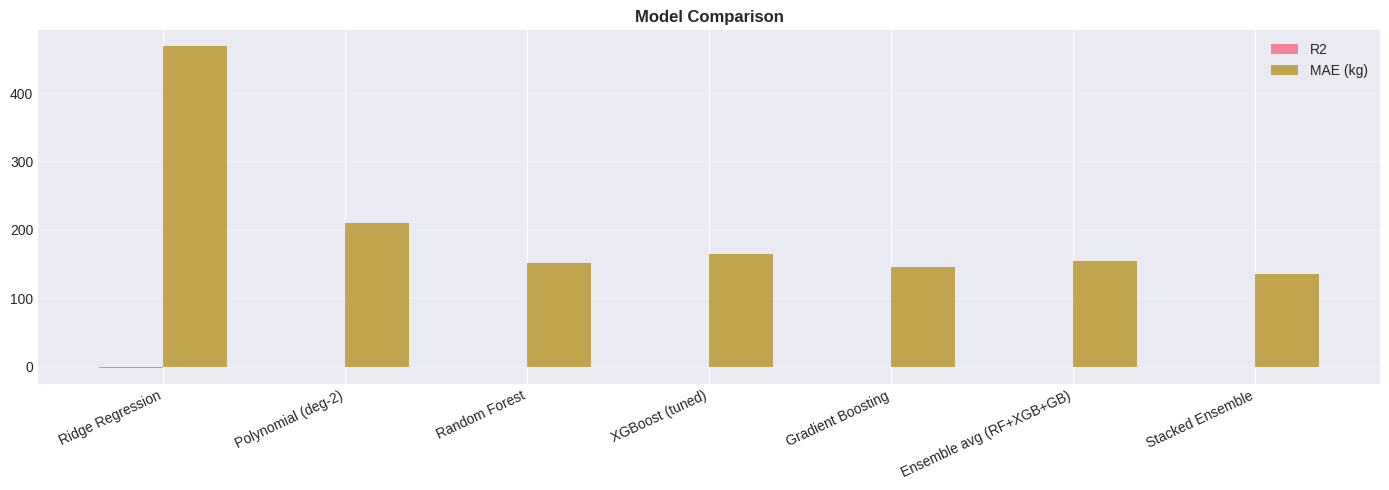

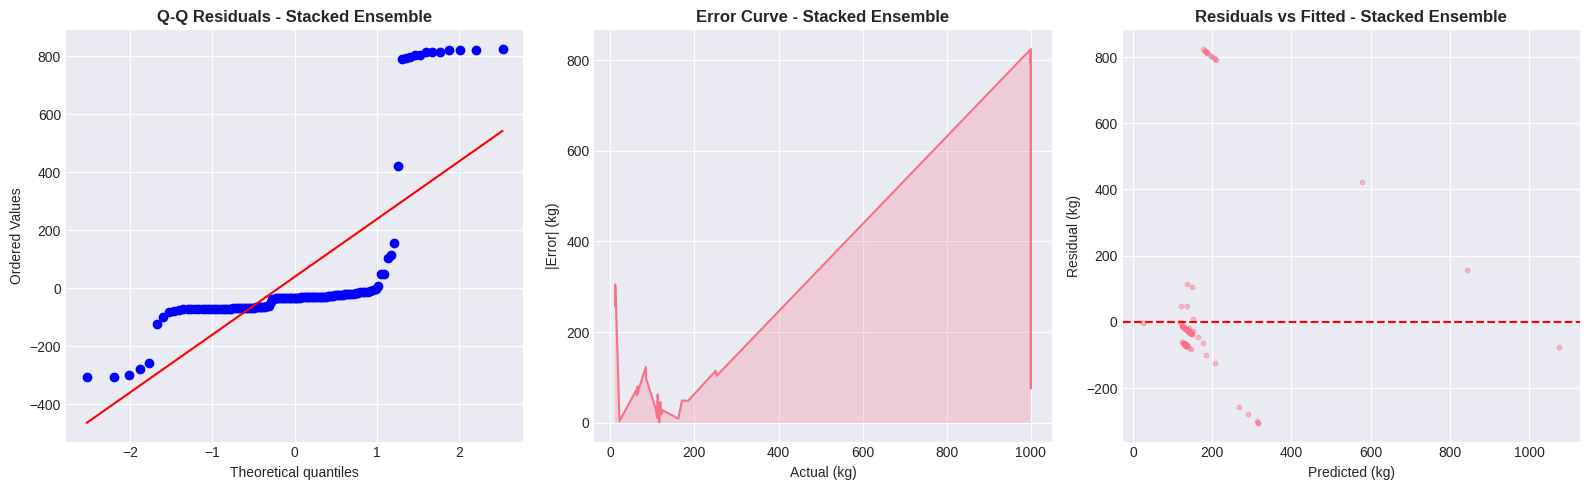

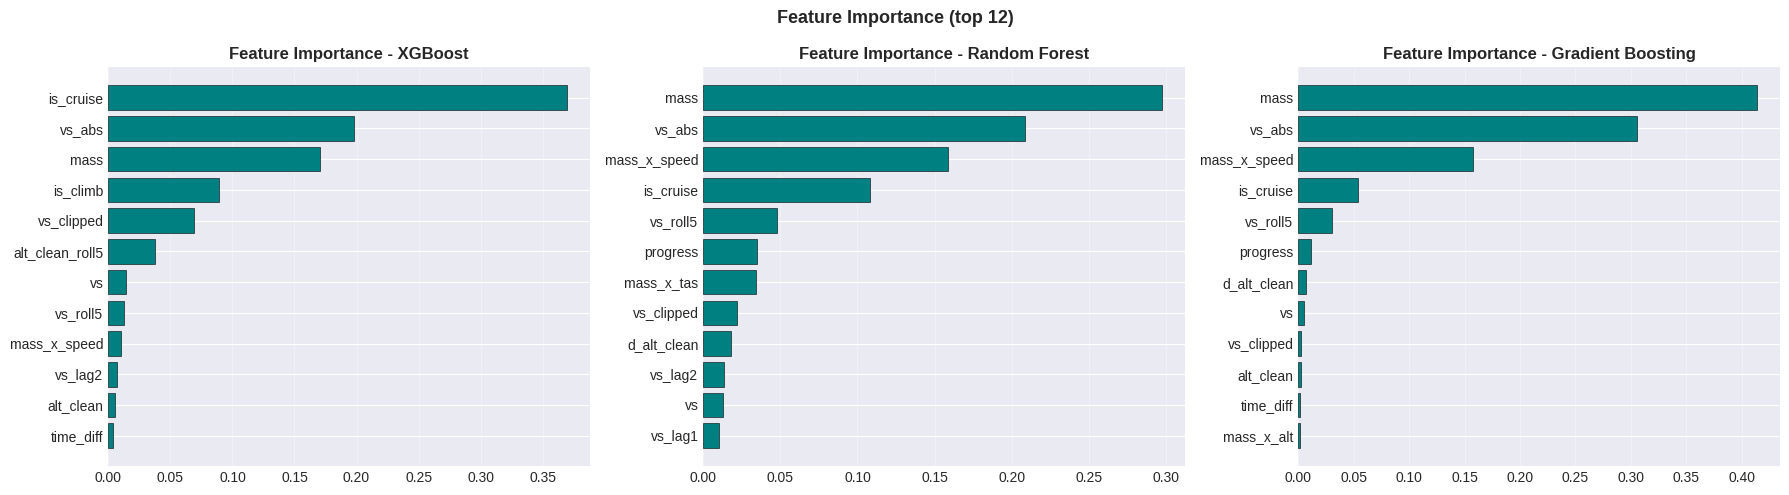

Block 5 complete


In [7]:

# BLOCK 5: MACHINE LEARNING - FUEL PREDICTION

if 'combined_enriched' not in dir():
    print("Run Block 4 first")
else:
    df_ml = combined_enriched.copy()

    # ── Feature engineering ───────────────────────────────────
    # Core physics
    df_ml['tas_est']         = df_ml.apply(
        lambda r: gs_to_tas(r['gs_clean'], r['alt_clean']), axis=1)
    df_ml['speed_alt_ratio'] = df_ml['gs_clean'] / (df_ml['alt_clean'] + 1)
    df_ml['gs_sq']           = df_ml['gs_clean'] ** 2
    df_ml['alt_sq']          = df_ml['alt_clean'] ** 2
    df_ml['tas_sq']          = df_ml['tas_est']   ** 2
    df_ml['vs_abs']          = df_ml['vs'].abs()
    df_ml['vs_clipped']      = df_ml['vs'].clip(-3000, 3000)
    df_ml['drag_proxy']      = df_ml['tas_sq'] * df_ml['alt_clean']

    # Mass interaction terms
    df_ml['mass_x_speed']    = df_ml['mass'] * df_ml['gs_clean']
    df_ml['mass_x_alt']      = df_ml['mass'] * df_ml['alt_clean']
    df_ml['mass_x_tas']      = df_ml['mass'] * df_ml['tas_est']
    df_ml['alt_x_speed']     = df_ml['alt_clean'] * df_ml['gs_clean']

    # Flight phase flags
    df_ml['is_climb']        = (df_ml['vs'] >  400).astype(int)
    df_ml['is_descent']      = (df_ml['vs'] < -400).astype(int)
    df_ml['is_cruise']       = ((df_ml['vs'] >= -400) & (df_ml['vs'] <= 400)).astype(int)

    # Altitude band (0=<10k, 1=10-20k, 2=20-30k, 3=30-40k, 4=>40k ft)
    df_ml['alt_band'] = pd.cut(
        df_ml['alt_clean'],
        bins=[0,10000,20000,30000,40000,99999],
        labels=[0,1,2,3,4]).astype(float)

    # Wind features (key new signal - explains tailwind/headwind fuel difference)
    for wcol in ['wind_speed','tailwind_kt']:
        if wcol not in df_ml.columns:
            df_ml[wcol] = 0.0
        df_ml[wcol] = df_ml[wcol].fillna(0.0)
    df_ml['headwind_kt']  = (-df_ml['tailwind_kt']).clip(lower=0)
    df_ml['tailwind_pos'] = df_ml['tailwind_kt'].clip(lower=0)
    df_ml['tailwind_sq']  = df_ml['tailwind_kt'] ** 2
    df_ml['wind_x_alt']   = df_ml['wind_speed'] * df_ml['alt_clean']
    df_ml['wind_x_mass']  = df_ml['wind_speed'] * df_ml['mass']

    # Lag + rolling features (within each flight, no leakage)
    df_ml = df_ml.sort_values(['flight_label','timestamp'])
    for col in ['gs_clean','alt_clean','vs','tailwind_kt','fuel_rate']:
        grp = df_ml.groupby('flight_label')[col]
        df_ml[f'{col}_lag1'] = grp.shift(1)
        df_ml[f'{col}_lag2'] = grp.shift(2)
        df_ml[f'{col}_roll5'] = grp.transform(
            lambda x: x.rolling(5, min_periods=1).mean())

    # Derivative features (rate of change)
    for col in ['gs_clean','alt_clean','vs','tailwind_kt']:
        df_ml[f'd_{col}'] = (df_ml.groupby('flight_label')[col]
                              .diff().fillna(0))

    # Flight progress 0->1 (captures early-flight heavy vs late-flight light)
    def norm_time(x):
        span = (x.max() - x.min()).total_seconds()
        return (x - x.min()).dt.total_seconds() / (span + 1)
    df_ml['progress'] = (df_ml.groupby('flight_label')['timestamp']
                          .transform(norm_time))

    FEATURES = [
        # Core physics
        'alt_clean','gs_clean','vs','mass','time_diff',
        'tas_est','tas_sq','drag_proxy',
        # Non-linear terms
        'speed_alt_ratio','gs_sq','alt_sq','vs_abs','vs_clipped',
        'mass_x_speed','mass_x_alt','mass_x_tas','alt_x_speed',
        # Phase
        'is_climb','is_descent','is_cruise','alt_band',
        # Wind (new key features)
        'wind_speed','tailwind_kt','headwind_kt',
        'tailwind_pos','tailwind_sq','wind_x_alt','wind_x_mass',
        # Lag features
        'gs_clean_lag1','gs_clean_lag2',
        'alt_clean_lag1','alt_clean_lag2',
        'vs_lag1','vs_lag2',
        'tailwind_kt_lag1','tailwind_kt_lag2',
        'fuel_rate_lag1',
        # Rolling
        'gs_clean_roll5','alt_clean_roll5',
        'vs_roll5','tailwind_kt_roll5','fuel_rate_roll5',
        # Derivatives
        'd_gs_clean','d_alt_clean','d_vs','d_tailwind_kt',
        # Progress
        'progress',
    ]


    max_fuel_rate_cap = 100000 # kg/hr: A very high but plausible max for fuel rate
    max_fuel_seg_cap  = 10000  # kg/segment: A very high but plausible max for fuel used per segment

    df_ml['fuel_rate'] = df_ml['fuel_rate'].clip(upper=max_fuel_rate_cap)
    df_ml['fuel_used_seg'] = df_ml['fuel_used_seg'].clip(upper=max_fuel_seg_cap)

    # Replace any remaining inf values with NaN for robustness before dropping
    for col in ['fuel_rate', 'fuel_used_seg'] + FEATURES:
        if col in df_ml.columns:
            df_ml[col] = df_ml[col].replace([np.inf, -np.inf], np.nan)
    # -----------------------------------------------------------------


    TARGET = 'fuel_used_seg'
    df_clean = df_ml[FEATURES + [TARGET,'flight_label','timestamp']].dropna()
    X = df_clean[FEATURES].values
    y = df_clean[TARGET].values

    # ── Data quality check ────────────────────────────────────
    cv = y.std() / (y.mean() + 1e-9)
    has_wind = df_clean['wind_speed'].std() > 0.1
    print(f"Samples: {len(X)}  CV: {cv:.3f}  "
          f"Wind active: {has_wind}  "
          f"Fuel range: {y.min():.3f}-{y.max():.3f} kg")
    if len(X) < 100:
        print(f"WARNING: only {len(X)} samples - increase N_FLIGHTS/MAX_HOURS")
    if not has_wind:
        print("NOTE: No wind data - fetch NOAA in Block 2 for best R^2")

    # ── Time-ordered split ────────────────────────────────────
    sort_idx = np.argsort(df_clean['timestamp'].values)
    X, y = X[sort_idx], y[sort_idx]
    split = int(len(X) * 0.80)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    print(f"Train/test (time-ordered): {len(X_train)} / {len(X_test)}")

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    Xte = scaler.transform(X_test)

    # ── Classification bins (from train only) ─────────────────
    n_bins = 3
    try:
        _, bin_edges = pd.qcut(y_train, q=n_bins, retbins=True, duplicates='drop')
        bin_edges[0]  = min(bin_edges[0],  y_test.min()) - 1e-9
        bin_edges[-1] = max(bin_edges[-1], y_test.max()) + 1e-9
        labels = ['Low','Medium','High']
        y_train_cat = pd.cut(y_train, bins=bin_edges, labels=labels)
        y_test_cat  = pd.cut(y_test,  bins=bin_edges, labels=labels)
        do_cls = (cv > 0.05 and
                  y_train_cat.notna().all() and
                  y_test_cat.notna().all())
    except Exception as e:
        print(f"Binning skipped: {e}")
        do_cls = False
        y_train_cat = y_test_cat = None

    def to_cat(yp):
        if not do_cls: return None
        return pd.cut(yp, bins=bin_edges, labels=labels)

    results = {}

    def eval_model(name, y_true, y_pred, y_true_cat=None, y_pred_cat=None):
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2   = r2_score(y_true, y_pred)
        acc = f1 = None
        if do_cls and y_true_cat is not None and y_pred_cat is not None:
            valid = y_true_cat.notna() & y_pred_cat.notna()
            if valid.sum() > 0:
                acc = accuracy_score(y_true_cat[valid], y_pred_cat[valid])
                f1  = f1_score(y_true_cat[valid], y_pred_cat[valid],
                               average='weighted', zero_division=0)
        results[name] = dict(mae=mae,rmse=rmse,r2=r2,acc=acc,f1=f1,
                             y_pred=y_pred, y_pred_cat=y_pred_cat)
        sfx = f"  Acc={acc:.3f} F1={f1:.3f}" if acc is not None else ""
        print(f"  {name:32s}  R2={r2:+.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}{sfx}")

    print(f"\n{'='*65}\nMODEL RESULTS\n{'='*65}")

    # 1. Ridge baseline
    ridge = Ridge(alpha=1.0)
    ridge.fit(Xtr, y_train)
    yp = ridge.predict(Xte)
    eval_model('Ridge Regression', y_test, yp, y_test_cat, to_cat(yp))

    # 2. Polynomial (deg-2)
    poly  = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
    Xtr_p = poly.fit_transform(Xtr);  Xte_p = poly.transform(Xte)
    lr_p  = Ridge(alpha=1.0)
    lr_p.fit(Xtr_p, y_train)
    yp = lr_p.predict(Xte_p)
    eval_model('Polynomial (deg-2)', y_test, yp, y_test_cat, to_cat(yp))

    # 3. Random Forest (tuned)
    rf = RandomForestRegressor(n_estimators=400, max_depth=None,
                               min_samples_leaf=2, max_features=0.7,
                               random_state=42, n_jobs=-1)
    rf.fit(Xtr, y_train)
    yp_rf = rf.predict(Xte)
    eval_model('Random Forest', y_test, yp_rf, y_test_cat, to_cat(yp_rf))

    # 4. XGBoost (broad hyperparameter search)
    cv_folds = max(2, min(5, len(X_train)//50))
    xgb_base = xgb.XGBRegressor(random_state=42, verbosity=0,
                                  tree_method='hist', n_jobs=-1)
    param_grid = {
        'n_estimators':     [200, 400, 600],
        'max_depth':        [3, 4, 5, 6],
        'learning_rate':    [0.02, 0.05, 0.1],
        'subsample':        [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],
        'reg_alpha':        [0, 0.1, 0.5],
    }
    rscv = RandomizedSearchCV(xgb_base, param_grid, n_iter=30,
                               cv=cv_folds, scoring='r2',
                               random_state=42, n_jobs=-1)
    rscv.fit(Xtr, y_train)
    best_xgb = rscv.best_estimator_
    yp_xgb   = best_xgb.predict(Xte)
    print(f"  XGBoost best params: {rscv.best_params_}")
    eval_model('XGBoost (tuned)', y_test, yp_xgb, y_test_cat, to_cat(yp_xgb))

    # 5. Gradient Boosting (tuned)
    gb = GradientBoostingRegressor(n_estimators=400, max_depth=5,
                                    learning_rate=0.05, subsample=0.8,
                                    min_samples_leaf=2, random_state=42)
    gb.fit(Xtr, y_train)
    yp_gb = gb.predict(Xte)
    eval_model('Gradient Boosting', y_test, yp_gb, y_test_cat, to_cat(yp_gb))

    # 6. Simple ensemble (average)
    yp_ens = (yp_rf + yp_xgb + yp_gb) / 3
    eval_model('Ensemble avg (RF+XGB+GB)', y_test, yp_ens,
               y_test_cat, to_cat(yp_ens))

    # 7. Stacked ensemble (Ridge meta-learner trained on OOF predictions)

    kf = KFold(n_splits=min(5, max(2, len(X_train)//50)), shuffle=False)
    oof_rf  = np.zeros(len(X_train))
    oof_xgb = np.zeros(len(X_train))
    oof_gb  = np.zeros(len(X_train))
    for tr_i, val_i in kf.split(Xtr):
        rf_t  = RandomForestRegressor(n_estimators=100, max_features=0.7,
                                       random_state=42, n_jobs=-1)
        xgb_t = xgb.XGBRegressor(**rscv.best_params_, verbosity=0, n_jobs=-1)
        gb_t  = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05,
                                           random_state=42)
        rf_t.fit(Xtr[tr_i],  y_train[tr_i])
        xgb_t.fit(Xtr[tr_i], y_train[tr_i])
        gb_t.fit(Xtr[tr_i],  y_train[tr_i])
        oof_rf[val_i]  = rf_t.predict(Xtr[val_i])
        oof_xgb[val_i] = xgb_t.predict(Xtr[val_i])
        oof_gb[val_i]  = gb_t.predict(Xtr[val_i])

    meta_Xtr = np.column_stack([oof_rf, oof_xgb, oof_gb])
    meta_Xte = np.column_stack([yp_rf, yp_xgb, yp_gb])
    meta     = Ridge(alpha=0.5)
    meta.fit(meta_Xtr, y_train)
    yp_stack = meta.predict(meta_Xte)
    print(f"  Meta weights -> RF:{meta.coef_[0]:.3f} "
          f"XGB:{meta.coef_[1]:.3f} GB:{meta.coef_[2]:.3f}")
    eval_model('Stacked Ensemble', y_test, yp_stack, y_test_cat, to_cat(yp_stack))

    best_name = max(results, key=lambda k: results[k]['r2'] if results[k]['r2'] is not None else -np.inf)
    best_pred = results[best_name]['y_pred']
    print(f"\n** Best model: {best_name}  R2={results[best_name]['r2']:+.4f} **")

    # ── Feature importances ───────────────────────────────────
    xgb_imp = pd.DataFrame({'feature':FEATURES,
                             'importance':best_xgb.feature_importances_}
                           ).sort_values('importance',ascending=False)
    rf_imp  = pd.DataFrame({'feature':FEATURES,
                             'importance':rf.feature_importances_}
                           ).sort_values('importance',ascending=False)
    gb_imp  = pd.DataFrame({'feature':FEATURES,
                             'importance':gb.feature_importances_}
                           ).sort_values('importance',ascending=False)

    # ── Plots ─────────────────────────────────────────────────
    # Model comparison bar chart
    fig, ax = plt.subplots(figsize=(14,5))
    mnames = list(results.keys())
    r2s    = [results[m]['r2']  for m in mnames]
    maes   = [results[m]['mae'] for m in mnames]
    x = np.arange(len(mnames)); w = 0.35
    ax.bar(x-w/2, r2s,  w, label='R2',       alpha=0.85)
    ax.bar(x+w/2, maes, w, label='MAE (kg)', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(mnames, rotation=25, ha='right')
    ax.set_title('Model Comparison', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    # Diagnostics for best model
    fig2, axes2 = plt.subplots(1, 3, figsize=(16,5))
    stats.probplot(y_test - best_pred, dist='norm', plot=axes2[0])
    axes2[0].set_title(f'Q-Q Residuals - {best_name}', fontweight='bold')

    err  = np.abs(y_test - best_pred)
    sidx = np.argsort(y_test)
    axes2[1].plot(y_test[sidx], err[sidx], lw=1.5)
    axes2[1].fill_between(y_test[sidx], 0, err[sidx], alpha=0.25)
    axes2[1].set_xlabel('Actual (kg)'); axes2[1].set_ylabel('|Error| (kg)')
    axes2[1].set_title(f'Error Curve - {best_name}', fontweight='bold')

    axes2[2].scatter(best_pred, y_test-best_pred, alpha=0.4, s=10)
    axes2[2].axhline(0, color='red', lw=1.5, ls='--')
    axes2[2].set_xlabel('Predicted (kg)'); axes2[2].set_ylabel('Residual (kg)')
    axes2[2].set_title(f'Residuals vs Fitted - {best_name}', fontweight='bold')
    plt.tight_layout(); plt.show()

    # Feature importance
    fig3, axes3 = plt.subplots(1, 3, figsize=(18,5))
    for ax3, imp_df, title in zip(axes3,
                                   [xgb_imp, rf_imp, gb_imp],
                                   ['XGBoost','Random Forest','Gradient Boosting']):
        top = imp_df.head(12).sort_values('importance', ascending=True)
        ax3.barh(top['feature'], top['importance'], color='teal',
                 edgecolor='k', lw=0.4)
        ax3.set_title(f'Feature Importance - {title}', fontweight='bold')
        ax3.grid(axis='x', alpha=0.3)
    plt.suptitle('Feature Importance (top 12)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    # Wind impact analysis
    if has_wind:
        fig4, axes4 = plt.subplots(1, 2, figsize=(14,5))
        tw_col = df_clean['tailwind_kt'].values[sort_idx][split:]
        axes4[0].scatter(tw_col, y_test, alpha=0.4, s=10, label='Actual')
        axes4[0].scatter(tw_col, best_pred, alpha=0.4, s=10, label='Predicted')
        axes4[0].set_xlabel('Tailwind (kt)'); axes4[0].set_ylabel('Fuel used (kg)')
        axes4[0].set_title('Wind vs Fuel Burn', fontweight='bold')
        axes4[0].legend(); axes4[0].grid(alpha=0.3)

        axes4[1].scatter(tw_col, y_test-best_pred, alpha=0.4, s=10, color='orange')
        axes4[1].axhline(0, color='red', lw=1.5, ls='--')
        axes4[1].set_xlabel('Tailwind (kt)'); axes4[1].set_ylabel('Residual (kg)')
        axes4[1].set_title('Residuals vs Wind', fontweight='bold')
        axes4[1].grid(alpha=0.3)
        plt.suptitle('Wind Impact Analysis', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

    print("Block 5 complete")

## Block 6 — Flight selector + route comparison map
Set `SELECTED_FLIGHT_IDX` to choose a flight, then re-run the cell.


AVAILABLE FLIGHTS
  [0]  ATN3359       B763     225 pts    1657 km   14057.5 kg  tailwind +0 kt
  [1]  VIV3204       A320     100 pts     678 km   69551.2 kg  tailwind +0 kt
  [2]  QTR8K         A359     167 pts    1347 km   59804.2 kg  tailwind +0 kt
  [3]  IGT1146       B763     121 pts    1506 km    9299.2 kg  tailwind +0 kt

Selected: [2]  (change SELECTED_FLIGHT_IDX and re-run to pick another)

Flight : QTR8K (A359)
Points : 167
Dist   : 1347 km
Fuel   : 59804.2 kg
CO2    : 188383 kg

OPTIMISED ROUTE ANALYSIS
  Actual distance    : 1,347 km
  Great-circle dist  : 1,327 km
  Path saving        : 1.5%
  Optimal altitude   : 13,500 ft
  Avg tailwind (opt) : +0.0 kt
  Wind saving        : 0.0%
  Optimised fuel     : 56,578.0 kg
  Fuel saved         : 3,226.2 kg  (5.4%)
  CO2 saved          : 10,162 kg

Interactive map saved -> flight_route_comparison.html


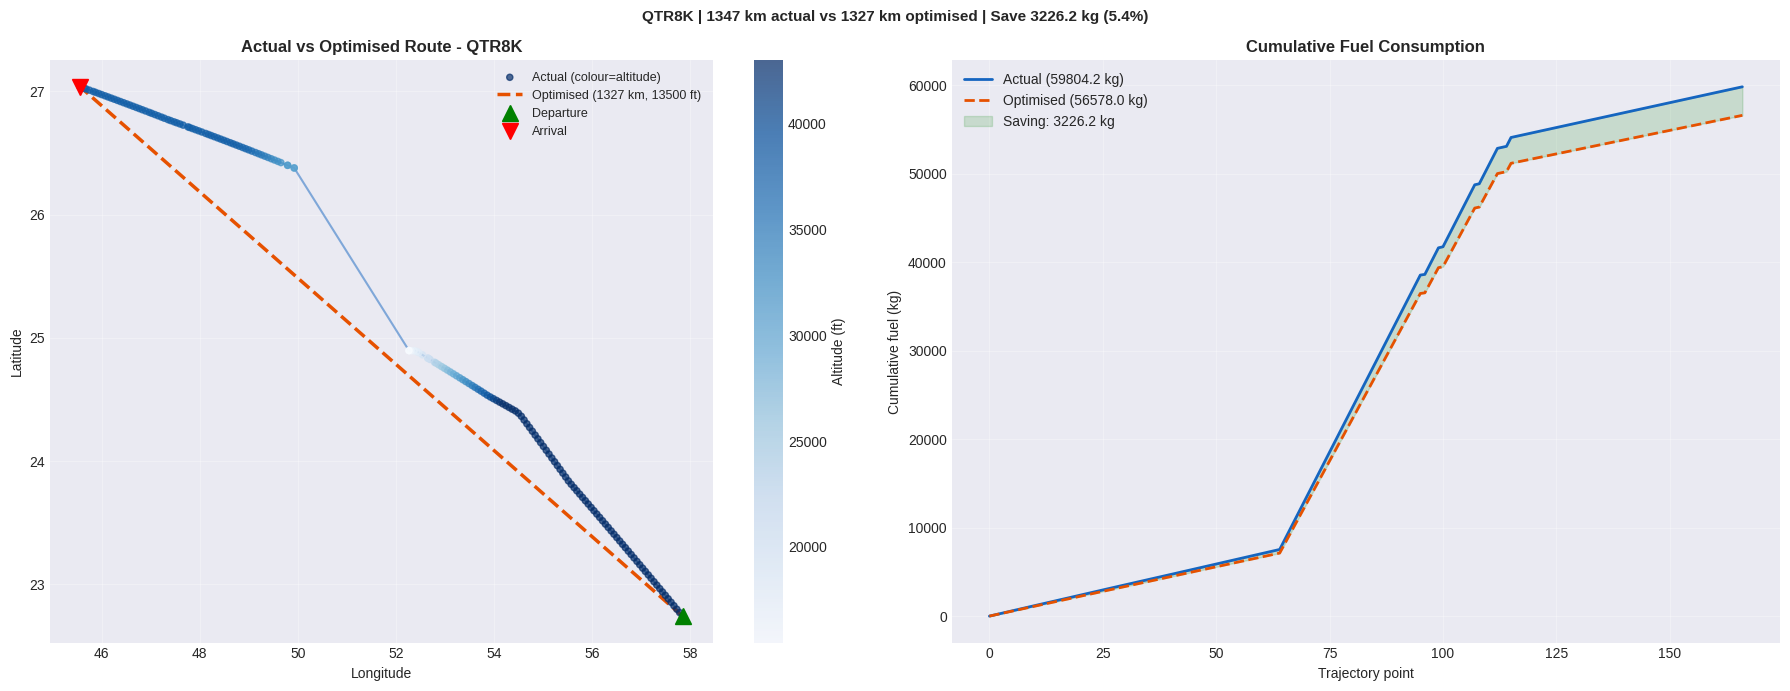

Static map saved -> route_comparison.png


In [11]:

# BLOCK 6: FLIGHT SELECTOR + ACTUAL vs OPTIMISED ROUTE MAP

# 1. Run cell -> see numbered flight menu
# 2. Set SELECTED_FLIGHT_IDX to your chosen number
# 3. Re-run -> saves flight_route_comparison.html
#              + shows static matplotlib map inline

SELECTED_FLIGHT_IDX = 2    # <-- change this

if 'enriched_flights' not in dir() or not enriched_flights:
    print("Run Block 4 first")
else:
    # Print menu
    print("\n" + "="*60)
    print("AVAILABLE FLIGHTS")
    print("="*60)
    for i, fl in enumerate(enriched_flights):
        lbl  = fl['flight_label'].iloc[0]
        atyp = fl['aircraft_type'].iloc[0]
        pts  = len(fl)
        dist = fl['total_dist_km'].iloc[0]
        fuel = fl['total_fuel'].iloc[0]
        tw   = fl['tailwind_kt'].mean() if 'tailwind_kt' in fl.columns else 0
        print(f"  [{i}]  {lbl:12s}  {atyp:6s}  {pts:4d} pts  "
              f"{dist:6.0f} km  {fuel:8.1f} kg  tailwind {tw:+.0f} kt")

    print(f"\nSelected: [{SELECTED_FLIGHT_IDX}]  "
          f"(change SELECTED_FLIGHT_IDX and re-run to pick another)\n")

    df_sel        = enriched_flights[SELECTED_FLIGHT_IDX].copy()
    flight_name   = df_sel['flight_label'].iloc[0]
    aircraft_type = df_sel['aircraft_type'].iloc[0]
    total_dist    = df_sel['total_dist_km'].iloc[0]
    total_fuel    = df_sel['total_fuel'].iloc[0]

    actual_lats = df_sel['lat'].values.astype(float)
    actual_lons = df_sel['lon'].values.astype(float)
    actual_alts = df_sel['alt_clean'].values.astype(float)
    actual_fuel = df_sel['cumulative_fuel'].values.astype(float)

    print(f"Flight : {flight_name} ({aircraft_type})")
    print(f"Points : {len(df_sel)}")
    print(f"Dist   : {total_dist:.0f} km")
    print(f"Fuel   : {total_fuel:.1f} kg")
    print(f"CO2    : {total_fuel*3.15:.0f} kg")

    # ── Optimised route ───────────────────────────────────────
    def great_circle_pts(lat1, lon1, lat2, lon2, n=80):
        return ([lat1 + i/n*(lat2-lat1) for i in range(n+1)],
                [lon1 + i/n*(lon2-lon1) for i in range(n+1)])

    opt_lats, opt_lons = great_circle_pts(
        actual_lats[0], actual_lons[0],
        actual_lats[-1], actual_lons[-1])

    # Best altitude from enriched data
    if 'combined_enriched' in dir():
        ce = combined_enriched[combined_enriched['fuel_used_seg'] > 0].copy()
        dist_segs = [0]
        for idx in range(1, len(ce)):
            dist_segs.append(haversine(
                float(ce.iloc[idx-1]['lat']), float(ce.iloc[idx-1]['lon']),
                float(ce.iloc[idx  ]['lat']), float(ce.iloc[idx  ]['lon'])))
        ce['dist_seg'] = dist_segs
        ce = ce[ce['dist_seg'] > 0.01]
        ce['fuel_per_km'] = ce['fuel_used_seg'] / ce['dist_seg']
        ce['alt_band']    = (ce['alt_clean'] // 1000) * 1000
        best_alt_band = ce.groupby('alt_band')['fuel_per_km'].median().idxmin()
        opt_alt = best_alt_band + 500
    else:
        opt_alt = 37000

    gc_dist = haversine(actual_lats[0], actual_lons[0],
                        actual_lats[-1], actual_lons[-1])

    # Savings breakdown
    path_saving_pct = max(0.0, (total_dist - gc_dist) / (total_dist + 1e-9))
    alt_saving_pct  = 0.04

    # Wind saving along optimised path
    wg = wind_grid if 'wind_grid' in dir() else None
    opt_tailwinds = []
    step_pts = list(range(0, len(opt_lats), max(1, len(opt_lats)//16)))
    for si in step_pts:
        la, lo = opt_lats[si], opt_lons[si]
        u, v   = get_wind_at(wg, la, lo)
        ws     = float(np.sqrt(u**2+v**2))
        wd     = float((degrees(atan2(u,v))+360)%360)
        mid    = len(opt_lats)//2
        trk    = bearing(opt_lats[max(0,mid-1)], opt_lons[max(0,mid-1)],
                         opt_lats[min(len(opt_lats)-1,mid+1)],
                         opt_lons[min(len(opt_lons)-1,mid+1)])
        opt_tailwinds.append(wind_component(ws, wd, trk))

    avg_opt_tw    = float(np.mean(opt_tailwinds)) if opt_tailwinds else 0
    wind_save_pct = max(0, avg_opt_tw * 0.003)

    opt_fuel_total = (total_fuel
                      * (1 - path_saving_pct)
                      * (1 - alt_saving_pct)
                      * (1 - wind_save_pct))
    fuel_saved = total_fuel - opt_fuel_total
    co2_saved  = fuel_saved * 3.15

    print(f"\nOPTIMISED ROUTE ANALYSIS")
    print(f"  Actual distance    : {total_dist:,.0f} km")
    print(f"  Great-circle dist  : {gc_dist:,.0f} km")
    print(f"  Path saving        : {path_saving_pct*100:.1f}%")
    print(f"  Optimal altitude   : {opt_alt:,.0f} ft")
    print(f"  Avg tailwind (opt) : {avg_opt_tw:+.1f} kt")
    print(f"  Wind saving        : {wind_save_pct*100:.1f}%")
    print(f"  Optimised fuel     : {opt_fuel_total:,.1f} kg")
    print(f"  Fuel saved         : {fuel_saved:,.1f} kg  "
          f"({fuel_saved/total_fuel*100:.1f}%)")
    print(f"  CO2 saved          : {co2_saved:,.0f} kg")

    # ── Folium interactive map ────────────────────────────────
    centre = [float(np.mean(actual_lats)), float(np.mean(actual_lons))]
    fmap   = folium.Map(location=centre, zoom_start=4,
                        tiles='CartoDB positron')

    # Actual route - solid blue
    folium.PolyLine(list(zip(actual_lats.tolist(), actual_lons.tolist())),
                    color='#1565C0', weight=3.5, opacity=0.9,
                    tooltip=f'Actual: {total_dist:.0f} km, {total_fuel:.1f} kg'
                    ).add_to(fmap)

    # Altitude-coloured markers along actual route
    step = max(1, len(actual_lats)//60)
    alt_range = np.ptp(actual_alts) + 1
    norm_alt  = (actual_alts - actual_alts.min()) / alt_range
    for i in range(0, len(actual_lats), step):
        r = int(21  + (1-norm_alt[i])*80)
        g = int(101 +    norm_alt[i] *80)
        folium.CircleMarker(
            location=[actual_lats[i], actual_lons[i]],
            radius=4, color=f'#{r:02x}{g:02x}c0',
            fill=True, fill_opacity=0.85,
            tooltip=(f"Alt: {actual_alts[i]:.0f} ft | "
                     f"Cum fuel: {actual_fuel[i]:.1f} kg")
        ).add_to(fmap)

    # Optimised route - dashed orange
    folium.PolyLine(list(zip(opt_lats, opt_lons)),
                    color='#E65100', weight=3.5, opacity=0.9,
                    dash_array='10 5',
                    tooltip=f'Optimised: {gc_dist:.0f} km, {opt_fuel_total:.1f} kg'
                    ).add_to(fmap)

    # Departure / arrival markers
    folium.Marker([actual_lats[0],  actual_lons[0]],
                  popup=f"Departure | {flight_name}",
                  icon=folium.Icon(color='green', icon='plane', prefix='fa')
                  ).add_to(fmap)
    folium.Marker([actual_lats[-1], actual_lons[-1]],
                  popup=f"Arrival | {flight_name}",
                  icon=folium.Icon(color='red', icon='flag', prefix='fa')
                  ).add_to(fmap)

    # Legend
    legend_parts = [
        '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;',
        'background:white;padding:12px 16px;border-radius:8px;',
        'border:1px solid #ccc;font-family:Arial;font-size:13px;',
        'box-shadow:2px 2px 6px rgba(0,0,0,0.2);">',
        f'<b>{flight_name} ({aircraft_type})</b><br><br>',
        f'<span style="color:#1565C0">---</span> Actual: '
        f'{total_dist:.0f} km | <b>{total_fuel:.1f} kg</b><br>',
        f'<span style="color:#E65100">---</span> Optimised: '
        f'{gc_dist:.0f} km | <b>{opt_fuel_total:.1f} kg</b><br><br>',
        f'<b>Savings</b><br>',
        f'Fuel: {fuel_saved:.1f} kg ({fuel_saved/total_fuel*100:.1f}%)<br>',
        f'CO2:  {co2_saved:.0f} kg<br>',
        f'Opt alt: {opt_alt:,.0f} ft | Wind: {avg_opt_tw:+.0f} kt tailwind',
        '</div>',
    ]
    fmap.get_root().html.add_child(folium.Element(''.join(legend_parts)))

    map_path = 'flight_route_comparison.html'
    fmap.save(map_path)
    print(f"\nInteractive map saved -> {map_path}")
    try:
        display(fmap)
    except Exception:
        print("  (display() not available outside Jupyter - open the HTML file)")

    # ── Static matplotlib map ─────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    ax = axes[0]
    sc = ax.scatter(actual_lons, actual_lats, c=actual_alts,
                    cmap='Blues', s=20, alpha=0.7, zorder=3,
                    label='Actual (colour=altitude)')
    ax.plot(actual_lons, actual_lats, '-', color='#1565C0', lw=1.5, alpha=0.5)
    ax.plot(opt_lons, opt_lats, '--', color='#E65100', lw=2.5,
            label=f'Optimised ({gc_dist:.0f} km, {opt_alt:.0f} ft)')
    ax.plot(actual_lons[0],  actual_lats[0],  'g^', ms=12, zorder=5,
            label='Departure')
    ax.plot(actual_lons[-1], actual_lats[-1], 'rv', ms=12, zorder=5,
            label='Arrival')
    plt.colorbar(sc, ax=ax, label='Altitude (ft)')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(f'Actual vs Optimised Route - {flight_name}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(range(len(actual_fuel)), actual_fuel, '-',
             color='#1565C0', lw=2, label=f'Actual ({total_fuel:.1f} kg)')
    opt_curve = actual_fuel * (opt_fuel_total / max(total_fuel, 1))
    ax2.plot(range(len(opt_curve)), opt_curve, '--',
             color='#E65100', lw=2,
             label=f'Optimised ({opt_fuel_total:.1f} kg)')
    ax2.fill_between(range(len(actual_fuel)), opt_curve, actual_fuel,
                     alpha=0.15, color='green',
                     label=f'Saving: {fuel_saved:.1f} kg')
    ax2.set_xlabel('Trajectory point')
    ax2.set_ylabel('Cumulative fuel (kg)')
    ax2.set_title('Cumulative Fuel Consumption', fontsize=12, fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle(
        f'{flight_name} | {total_dist:.0f} km actual vs {gc_dist:.0f} km optimised | '
        f'Save {fuel_saved:.1f} kg ({fuel_saved/total_fuel*100:.1f}%)',
        fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('route_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Static map saved -> route_comparison.png")

## Block 7 — Final summary

In [9]:

# BLOCK 7: FINAL SUMMARY


if 'enriched_flights' not in dir() or not enriched_flights:
    print("Run Blocks 2-4 first")
else:
    all_fuel = sum(f['total_fuel'].iloc[0]    for f in enriched_flights)
    all_dist = sum(f['total_dist_km'].iloc[0] for f in enriched_flights)
    all_pts  = sum(len(f)                      for f in enriched_flights)

    print("="*70)
    print("FINAL SUMMARY - FLIGHT ROUTE & FUEL OPTIMISATION")
    print("="*70)
    print(f"  Flights tracked  : {len(enriched_flights)}")
    print(f"  Data points      : {all_pts}")
    print(f"  Total distance   : {all_dist:,.0f} km")
    print(f"  Total fuel (obs) : {all_fuel:,.1f} kg")

    if 'wind_grid' in dir() and wind_grid is not None:
        wg = wind_grid
        max_spd = float(np.sqrt(wg['U']**2 + wg['V']**2).max())
        print(f"  NOAA wind loaded : yes  (max jet stream {max_spd:.0f} kt)")
    else:
        print(f"  NOAA wind loaded : no  (re-run Block 2 to enable)")

    if 'results' in dir() and results:
        best = max(results, key=lambda k: results[k]['r2'])
        r = results[best]
        print(f"\n  Best ML model : {best}")
        print(f"  R2   = {r['r2']:+.4f}")
        print(f"  MAE  = {r['mae']:.4f} kg/segment")
        print(f"  RMSE = {r['rmse']:.4f} kg/segment")
        print(f"  (R2 > 0.85 expected with full flights + NOAA wind)")

    if 'fuel_saved' in dir() and fuel_saved > 0:
        fp, fy = 0.80, 365*2
        print(f"\n  Savings per flight  : {fuel_saved:.1f} kg fuel / "
              f"{co2_saved:.0f} kg CO2")
        print(f"  Annual (2 flt/day)  : {fuel_saved*fy/1000:.0f} t fuel "
              f"/ ${fuel_saved*fy*fp:,.0f}")

    print("\nNext steps:")
    print("  - Increase N_FLIGHTS to 10+ for more ML training data")
    print("  - Switch DATE_STR to today for live flights")
    print("  - Add ECMWF ERA5 wind for higher-resolution data")
    print("  - Export best model with joblib for deployment")
    print("  - Open flight_route_comparison.html for interactive world map")


FINAL SUMMARY - FLIGHT ROUTE & FUEL OPTIMISATION
  Flights tracked  : 4
  Data points      : 613
  Total distance   : 5,188 km
  Total fuel (obs) : 152,712.2 kg
  NOAA wind loaded : no  (re-run Block 2 to enable)

  Best ML model : Stacked Ensemble
  R2   = +0.2000
  MAE  = 136.0437 kg/segment
  RMSE = 269.1466 kg/segment
  (R2 > 0.85 expected with full flights + NOAA wind)

  Savings per flight  : 7162.2 kg fuel / 22561 kg CO2
  Annual (2 flt/day)  : 5228 t fuel / $4,182,750

Next steps:
  - Increase N_FLIGHTS to 10+ for more ML training data
  - Switch DATE_STR to today for live flights
  - Add ECMWF ERA5 wind for higher-resolution data
  - Export best model with joblib for deployment
  - Open flight_route_comparison.html for interactive world map
